# The CIFAR-10 Dataset
The [CIFAR-10 and the CIFAR-100](https://www.cs.toronto.edu/~kriz/cifar.html) datastes are important benchmarks in image processing. Here we will  build, train, and evaluate a feedforward neural network on the CIFAR‑10 dataset using TensorFlow.

**Objective:**
Design and implement a feedforward neural network to classify images in the CIFAR‑10 dataset. You will preprocess the data, build and train the model, evaluate its performance, and answer analytical questions regarding the design choices and possible enhancements.

The CIFAR-10 dataset consists of 60000 32x32 color images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

Task 1:

1. Load the Dataset:
  * Import TensorFlow and the necessary modules from Keras.
  * Load the CIFAR‑10 dataset using the `cifar10.load_data()` method in the `kears` module. As the link says, this dataset is approximately 163 Mb and might take some time to download.
  * Use the `imshow()` method in Pyplot to visualize 10 randomly selected train and test images. If the images look too grainy, play around with the `interpolation` argument to smooth out pixel values.

2. Normalize the Data:
  * Convert the image pixel values from integers to floats.
  * Scale the images such that pixel values are in the range [0, 1].

3. Flatten and One‑Hot Encode:
  * Reshape each 32x32x3 image into a 3072‑dimensional vector.
  * Convert the labels to one‑hot encoding for 10 classes using the `to_categorical()` method in [Kears](https://keras.io/api/utils/).

In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f"Training set: {x_train.shape}, Test set: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training set: (50000, 32, 32, 3), Test set: (10000, 32, 32, 3)


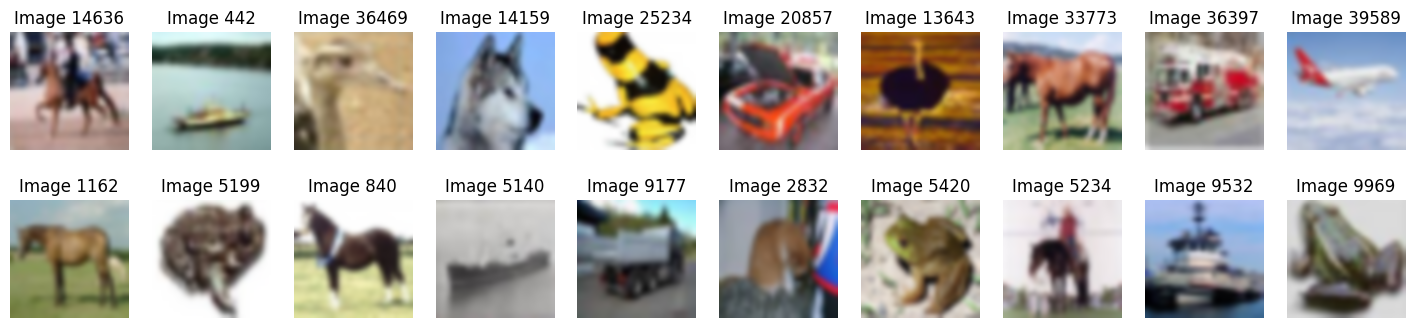

In [16]:
plt.figure(figsize=(18, 8))
for i in range(10):
    idx_train = np.random.randint(0, len(x_train))
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[idx_train], interpolation='bicubic')
    plt.title(f"Image {idx_train}")
    plt.axis('off')
    idx_test = np.random.randint(0, len(x_test))
    plt.subplot(2, 10, i+11)
    plt.imshow(x_test[idx_test], interpolation='bicubic')
    plt.title(f"Image {idx_test}")
    plt.axis('off')
plt.show()

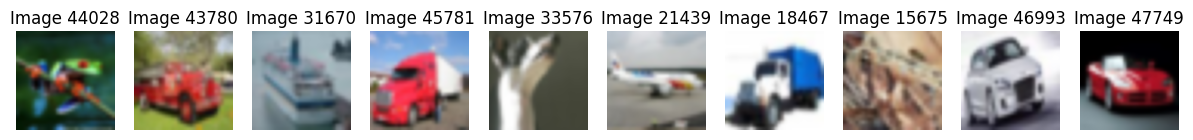

In [9]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [17]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)
y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

print(f"Flattened shape: {x_train_flat.shape[1]} dimensions")

Flattened shape: 3072 dimensions


## Building the Neural Network Model
Task 2:

1. Define the Input Layer:
  * Create a model input that expects a vector of size 3072.

2. Add Hidden Layers:
  * Use a loop or add layers individually to include 5 hidden Dense layers.
  * Each hidden layer should have 512 neurons and use the ReLU activation function.

3. Add the Output Layer:
  * Add a Dense layer with 10 neurons and use the softmax activation function to classify the images into 10 categories.

4. Compile the Model:
  * Compile using the Adam optimizer, categorical crossentropy as the loss function, and include accuracy as a metric.

5. Print a summary of the model. How many weights does this model have?

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_flat.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629,130 (10.03 MB)

 Trainable params: 2,629,130 (10.03 MB)

 Non-trainable params: 0 (0.00 B)

This model has a total of 2,629,130 weights.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629,130 (10.03 MB)

 Trainable params: 2,629,130 (10.03 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training and Evaluation
Task 3:

1. Train the Model:
  * Train the model for 20 epochs with a batch size of 128.
  * Use the test data as validation data during training (pass `validation_data`).

2. Evaluate the Model:
  * Evaluate the model on the test set.
  * Print and report the test loss and test accuracy.

In [21]:
history = model.fit(
    x_train_flat, y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_flat, y_test_onehot),
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2471 - loss: 2.0259 - val_accuracy: 0.3798 - val_loss: 1.7197
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3830 - loss: 1.7095 - val_accuracy: 0.4244 - val_loss: 1.6136
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4226 - loss: 1.6042 - val_accuracy: 0.4202 - val_loss: 1.6146
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4357 - loss: 1.5669 - val_accuracy: 0.4603 - val_loss: 1.5252
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4638 - loss: 1.5001 - val_accuracy: 0.4733 - val_loss: 1.4900
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4741 - loss: 1.4500 - val_accuracy: 0.4606 - val_loss: 1.4998
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4940 - loss: 1.4070 - val_accuracy: 0.4681 - val_loss: 1.4867
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4997 - loss: 1.3802 - val_accu

In [22]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_onehot, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 1.5624
Test accuracy: 0.5041


Epoch 1/20
391/391 - 24s - 62ms/step - accuracy: 0.3027 - loss: 1.8992 - val_accuracy: 0.3715 - val_loss: 1.7435
Epoch 2/20
391/391 - 40s - 103ms/step - accuracy: 0.3817 - loss: 1.7052 - val_accuracy: 0.4003 - val_loss: 1.6369
Epoch 3/20
391/391 - 40s - 102ms/step - accuracy: 0.4152 - loss: 1.6188 - val_accuracy: 0.4483 - val_loss: 1.5497
Epoch 4/20
391/391 - 21s - 55ms/step - accuracy: 0.4426 - loss: 1.5537 - val_accuracy: 0.4369 - val_loss: 1.5654
Epoch 5/20
391/391 - 40s - 102ms/step - accuracy: 0.4619 - loss: 1.5010 - val_accuracy: 0.4528 - val_loss: 1.5288
Epoch 6/20
391/391 - 21s - 54ms/step - accuracy: 0.4727 - loss: 1.4643 - val_accuracy: 0.4663 - val_loss: 1.4923
Epoch 7/20
391/391 - 40s - 102ms/step - accuracy: 0.4870 - loss: 1.4219 - val_accuracy: 0.4852 - val_loss: 1.4536
Epoch 8/20
391/391 - 21s - 54ms/step - accuracy: 0.4984 - loss: 1.3876 - val_accuracy: 0.4828 - val_loss: 1.4601
Epoch 9/20
391/391 - 22s - 55ms/step - accuracy: 0.5135 - loss: 1.3519 - val_accuracy: 0.493